# Módulo 12 · Comparación: Auto ARIMA vs. Prophet

Curso: **Series Temporales con R y Python** (Frogames Formación).

Código de acompañamiento de la lección `12-prediciendo-el-futuro/06-comparacion-auto-arima-vs-prophet`.

Dos modelos, mismo dataset (`AirPassengers`), mismo train/test split, misma métrica de error (**RMSE**). No se compara "cuál es más fácil de usar" ni "cuál está más de moda" — se compara cuál predice mejor, con un número, sobre datos que ninguno de los dos modelos ha visto durante el entrenamiento.

## Carga y train/test split

Se reservan los últimos 24 meses (2 años) como test — nunca se mezcla el orden temporal, la misma regla del Módulo 2.

In [1]:
import pandas as pd

df = pd.read_csv("airline_passengers.csv")
df["ds"] = pd.to_datetime(df["month"], format="%Y-%m")
df["y"] = df["passengers"]
df = df[["ds", "y"]]

h = 24
train, test = df.iloc[:-h], df.iloc[-h:]
print("train:", train.shape, "  test:", test.shape)

train: (120, 2)   test: (24, 2)


## Modelo 1 — Auto ARIMA (`pmdarima`)

Se le da la serie de entrenamiento en escala original (sin diferenciar a mano) y se deja que el propio `auto_arima` decida `(p,d,q)(P,D,Q)[12]` — estacional, con periodo 12 porque son datos mensuales con estacionalidad anual clara (ver Módulo 3).

In [2]:
import pmdarima as pm

modelo_arima = pm.auto_arima(train["y"], seasonal=True, m=12,
                              suppress_warnings=True, stepwise=True, trace=False)
print(modelo_arima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  120
Model:             SARIMAX(2, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -400.431
Date:                            Thu, 17 Sep 2026   AIC                            808.863
Time:                                    09:19:54   BIC                            819.592
Sample:                                         0   HQIC                           813.213
                                            - 120                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      4.2859      2.035      2.106      0.035       0.297       8.275
ar.L1          0.6783      0.100   

In [3]:
pred_arima, conf_arima = modelo_arima.predict(n_periods=h, return_conf_int=True)

## Modelo 2 — Prophet

Mismo dataset, mismo horizonte, sin ningún ajuste manual de estacionalidad — Prophet la detecta directamente sobre la escala original.

In [4]:
from prophet import Prophet

m = Prophet(seasonality_mode="multiplicative")
m.fit(train)
future = m.make_future_dataframe(periods=h, freq="MS")
forecast_prophet = m.predict(future)
pred_prophet = forecast_prophet["yhat"].iloc[-h:].values

Importing plotly failed. Interactive plots will not work.


09:19:55 - cmdstanpy - INFO - Chain [1] start processing


09:19:55 - cmdstanpy - INFO - Chain [1] done processing


## RMSE cabeza a cabeza

In [5]:
import numpy as np

rmse_arima = np.sqrt(np.mean((pred_arima - test["y"].values) ** 2))
rmse_prophet = np.sqrt(np.mean((pred_prophet - test["y"].values) ** 2))

tabla = pd.DataFrame({
    "modelo": ["Auto ARIMA", "Prophet"],
    "RMSE": [round(rmse_arima, 2), round(rmse_prophet, 2)]
})
print(tabla)
print()
print("media real del tramo test:", round(test["y"].mean(), 2))

       modelo   RMSE
0  Auto ARIMA  47.23
1     Prophet  30.73

media real del tramo test: 452.25


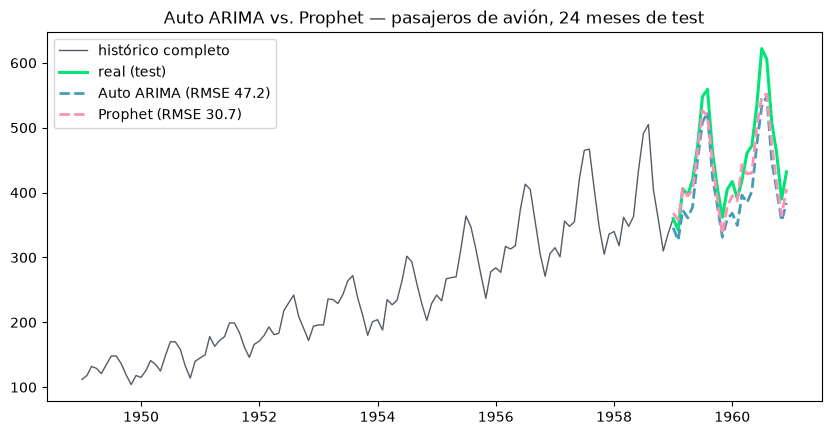

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(df["ds"], df["y"], color="#555b66", linewidth=1, label="histórico completo")
ax.plot(test["ds"], test["y"].values, color="#00e676", linewidth=2.2, label="real (test)")
ax.plot(test["ds"], pred_arima, color="#449cb9", linestyle="--", linewidth=2, label=f"Auto ARIMA (RMSE {rmse_arima:.1f})")
ax.plot(test["ds"], pred_prophet, color="#ff8fb3", linestyle="--", linewidth=2, label=f"Prophet (RMSE {rmse_prophet:.1f})")
ax.legend()
ax.set_title("Auto ARIMA vs. Prophet — pasajeros de avión, 24 meses de test")
plt.savefig("comparacion_arima_prophet.png", dpi=110, bbox_inches="tight")
plt.show()

## Cómo leer el resultado (sin sacar una conclusión universal)

El RMSE más bajo de los dos, **en esta serie concreta y con este horizonte concreto**, es el que gana aquí — el número de arriba lo dice sin ambigüedad. Pero la conclusión que hay que llevarse **no** es "el modelo ganador es siempre mejor": es que la comparación cabeza a cabeza con la misma métrica, el mismo train/test split y el mismo horizonte es la única forma honesta de elegir entre dos modelos — no la facilidad de uso, no la fama de la librería, no cuál da un gráfico más bonito por defecto. Con otra serie, otro horizonte o otro tipo de estacionalidad, el resultado puede invertirse perfectamente: Auto ARIMA suele imponerse en series más cortas y con estructura ARIMA limpia; Prophet suele defenderse mejor cuando hay festivos, cambios de tendencia (*changepoints*) explícitos o series muy largas con estacionalidad múltiple.

## Validacion robusta: rolling-origin cross-validation

Un solo train/test split es un solo numero. Se repite la comparacion con tres ventanas de rolling-origin CV -walk-forward manual para Auto ARIMA, `cross_validation`/`performance_metrics` de Prophet para el otro- y una segunda y tercera metrica (MAE, MAPE), en vez de quedarse con un unico RMSE.

In [7]:
horizonte, paso, origen_inicial = 12, 12, 84
resultados = []
origen = origen_inicial
while origen + horizonte <= len(train):
    train_cv, test_cv = train.iloc[:origen], train.iloc[origen: origen + horizonte]

    modelo_cv = pm.auto_arima(train_cv["y"], seasonal=True, m=12,
                               suppress_warnings=True, stepwise=True, trace=False)
    pred_cv = modelo_cv.predict(n_periods=horizonte)

    rmse = np.sqrt(np.mean((pred_cv.values - test_cv["y"].values) ** 2))
    mae = np.mean(np.abs(pred_cv.values - test_cv["y"].values))
    mape = np.mean(np.abs((pred_cv.values - test_cv["y"].values) / test_cv["y"].values)) * 100
    resultados.append({"test": f"{test_cv['ds'].iloc[0]:%Y-%m} a {test_cv['ds'].iloc[-1]:%Y-%m}",
                        "RMSE": round(rmse, 2), "MAE": round(mae, 2), "MAPE": round(mape, 2)})
    origen += paso

tabla_cv_arima = pd.DataFrame(resultados)
print(tabla_cv_arima.to_string(index=False))
print()
print("Auto ARIMA walk-forward (%d folds) -> RMSE medio: %.2f  MAE medio: %.2f  MAPE medio: %.2f%%" %
      (len(tabla_cv_arima), tabla_cv_arima["RMSE"].mean(), tabla_cv_arima["MAE"].mean(), tabla_cv_arima["MAPE"].mean()))


             test  RMSE   MAE  MAPE
1956-01 a 1956-12 21.04 17.54  5.00
1957-01 a 1957-12 15.80 12.08  2.98
1958-01 a 1958-12 21.50 19.41  5.38

Auto ARIMA walk-forward (3 folds) -> RMSE medio: 19.45  MAE medio: 16.34  MAPE medio: 4.45%


In [8]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(m, initial="2190 days", period="365 days", horizon="365 days")
print("folds (cutoffs unicos):", df_cv["cutoff"].nunique())

filas = []
for c, g in df_cv.groupby("cutoff"):
    rmse_f = np.sqrt(np.mean((g["yhat"].values - g["y"].values) ** 2))
    mae_f = np.mean(np.abs(g["yhat"].values - g["y"].values))
    mape_f = np.mean(np.abs((g["yhat"].values - g["y"].values) / g["y"].values)) * 100
    filas.append({"cutoff": c.date(), "test": f"{g['ds'].min():%Y-%m} a {g['ds'].max():%Y-%m}",
                   "RMSE": round(rmse_f, 2), "MAE": round(mae_f, 2), "MAPE": round(mape_f, 2)})
tabla_cv_prophet = pd.DataFrame(filas)
print(tabla_cv_prophet.to_string(index=False))
print()
print("Prophet CV (%d folds) -> RMSE medio: %.2f  MAE medio: %.2f  MAPE medio: %.2f%%" %
      (len(tabla_cv_prophet), tabla_cv_prophet["RMSE"].mean(), tabla_cv_prophet["MAE"].mean(), tabla_cv_prophet["MAPE"].mean()))

df_perf = performance_metrics(df_cv, rolling_window=1)
print()
print("performance_metrics() agregado sobre las 36 predicciones combinadas:")
print(df_perf[["horizon", "rmse", "mae", "mape"]].to_string(index=False))


  0%|          | 0/3 [00:00<?, ?it/s]

09:20:00 - cmdstanpy - INFO - Chain [1] start processing


09:20:00 - cmdstanpy - INFO - Chain [1] done processing


09:20:00 - cmdstanpy - INFO - Chain [1] start processing


09:20:00 - cmdstanpy - INFO - Chain [1] done processing


09:20:00 - cmdstanpy - INFO - Chain [1] start processing


09:20:00 - cmdstanpy - INFO - Chain [1] done processing


folds (cutoffs unicos): 3
    cutoff              test  RMSE   MAE  MAPE
1955-12-02 1956-01 a 1956-12 11.31  8.33  2.43
1956-12-01 1957-01 a 1957-12 10.94  9.73  2.77
1957-12-01 1958-01 a 1958-12 35.39 32.66  9.04

Prophet CV (3 folds) -> RMSE medio: 19.21  MAE medio: 16.91  MAPE medio: 4.75%

performance_metrics() agregado sobre las 36 predicciones combinadas:
 horizon     rmse       mae     mape
365 days 22.36363 16.909859 0.047465


**Con un solo split, Prophet ganaba claro (RMSE 30,73 vs. 47,23). Con rolling-origin CV sobre los mismos 3 folds, el resultado es un empate tecnico**: RMSE medio 19,45 (Auto ARIMA) vs. 19,21 (Prophet), con Auto ARIMA por delante en MAE y MAPE. En 2 de los 3 folds Prophet predice claramente mejor, pero el fold de 1958 se dispara (RMSE 35,39) y borra su ventaja media. Ningun numero esta mal calculado: es la validacion robusta la que revela que el split unico no era representativo. Es, literalmente, el motivo por el que esta comparacion merece mas de un numero.